In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [30]:
df = pd.read_csv('../data/df_clean_graficos.csv')
df.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,mcc_code,categoria,is_fraud,fecha
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,Sin Error,5499,Miscellaneous Food Stores,0,2010-01-01
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,Sin Error,5311,Department Stores,0,2010-01-01
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,Sin Error,4829,Money Transfer,0,2010-01-01
3,7475331,2010-01-01 00:05:00,430,2860,200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,Sin Error,4829,Money Transfer,-1,2010-01-01
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,Sin Error,5813,Drinking Places (Alcoholic Beverages),0,2010-01-01


### Pregunta 16 -  Gráfico de barras: monto total por categoría

In [31]:
monto_categoria = (df[df['amount'] > 0]
    .groupby('categoria')['amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
monto_categoria.columns = ['categoria', 'monto_total']

top_10 = monto_categoria.head(10)
bottom_10 = monto_categoria.tail(10)

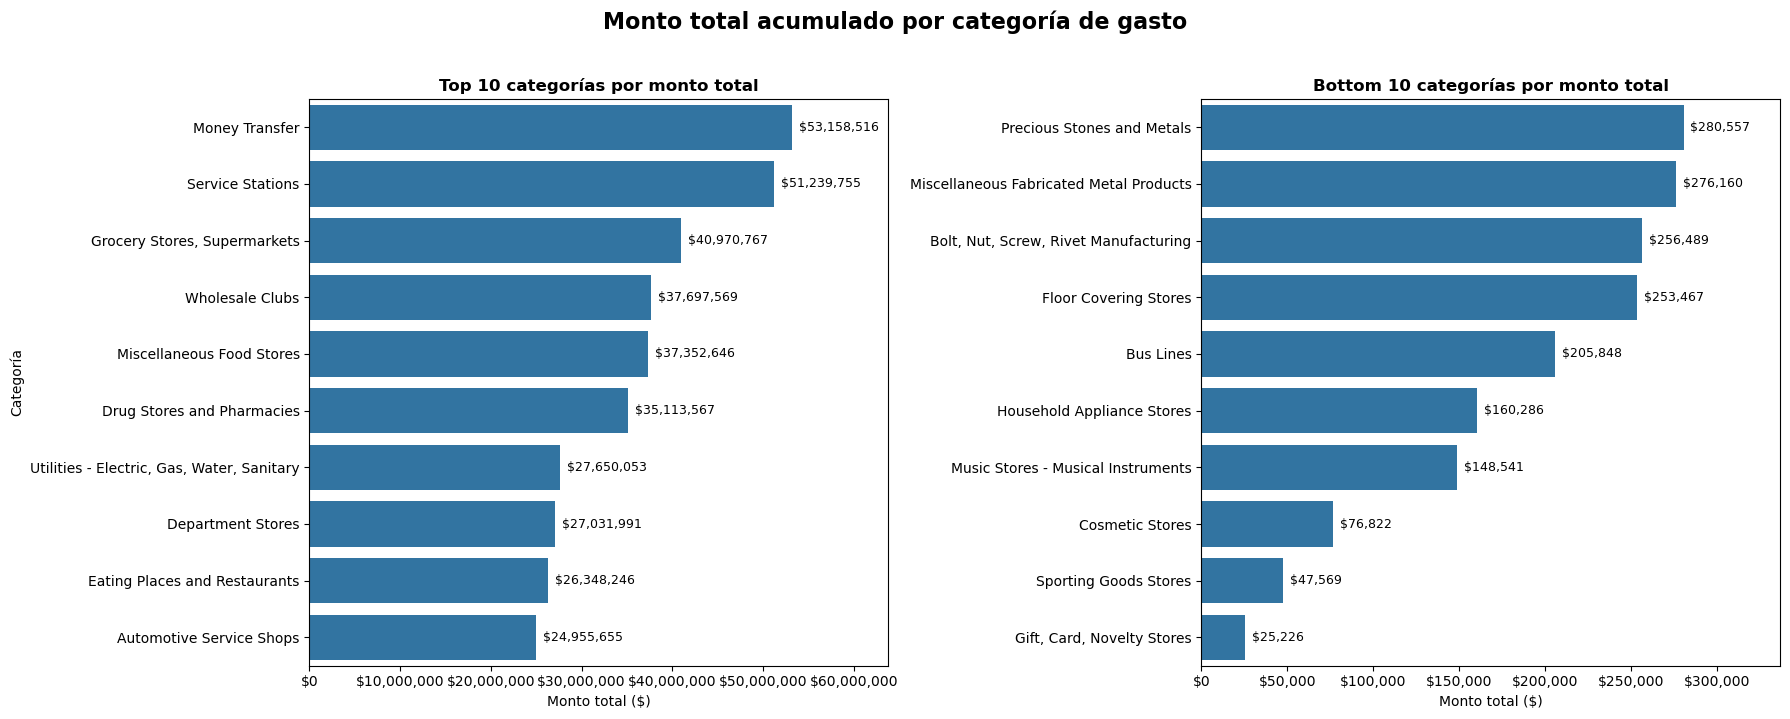

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(18,7))
# Grafico 1
sns.barplot(data=top_10, x='monto_total', y='categoria', ax=ax[0])
ax[0].set_title('Top 10 categorías por monto total', fontweight='bold')
ax[0].set_xlabel('Monto total ($)')
ax[0].set_ylabel('Categoría')

# Grafico 2
sns.barplot(data=bottom_10, x='monto_total', y='categoria', ax=ax[1])
ax[1].set_title('Bottom 10 categorías por monto total', fontweight='bold')
ax[1].set_xlabel('Monto total ($)')
ax[1].set_ylabel('')  # Sin label porque ya lo tiene el de la izquierda

# Agregar etiquetas de valor en cada barra
for container in ax[1].containers:
    ax[1].bar_label(container, fmt='${:,.0f}', padding=5, fontsize=9)
    
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='${:,.0f}', padding=5, fontsize=9)

# Formato para eje X
formatter = FuncFormatter(lambda x, pos: f'${x:,.0f}')

ax[0].xaxis.set_major_formatter(formatter)
ax[1].xaxis.set_major_formatter(formatter)
ax[0].set_xlim(0, top_10['monto_total'].max() * 1.2)
ax[1].set_xlim(0, bottom_10['monto_total'].max() * 1.2)

plt.suptitle('Monto total acumulado por categoría de gasto', fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

### Pregunta 17 - Gráfico de línea: volumen de transacciones por mes

In [33]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['yaer'] = df['date'].dt.year

In [34]:
meses = {1: 'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun', 7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}

In [35]:
# Datos para el grafico
tendencia = (df
    .groupby(['month','yaer'])['amount']
    .sum()
    .reset_index()
)
tendencia['periodo'] = pd.to_datetime(tendencia['yaer'].astype(str) + '-' + tendencia['month'].astype(str), format='%Y-%m')

# Datos para el grafico 2
estacional = (df
    .groupby('month')['amount']
    .sum()
    .reset_index()
)
estacional['name_month'] = estacional['month'].map(meses)
mes_max = estacional.loc[estacional['amount'].idxmax()]

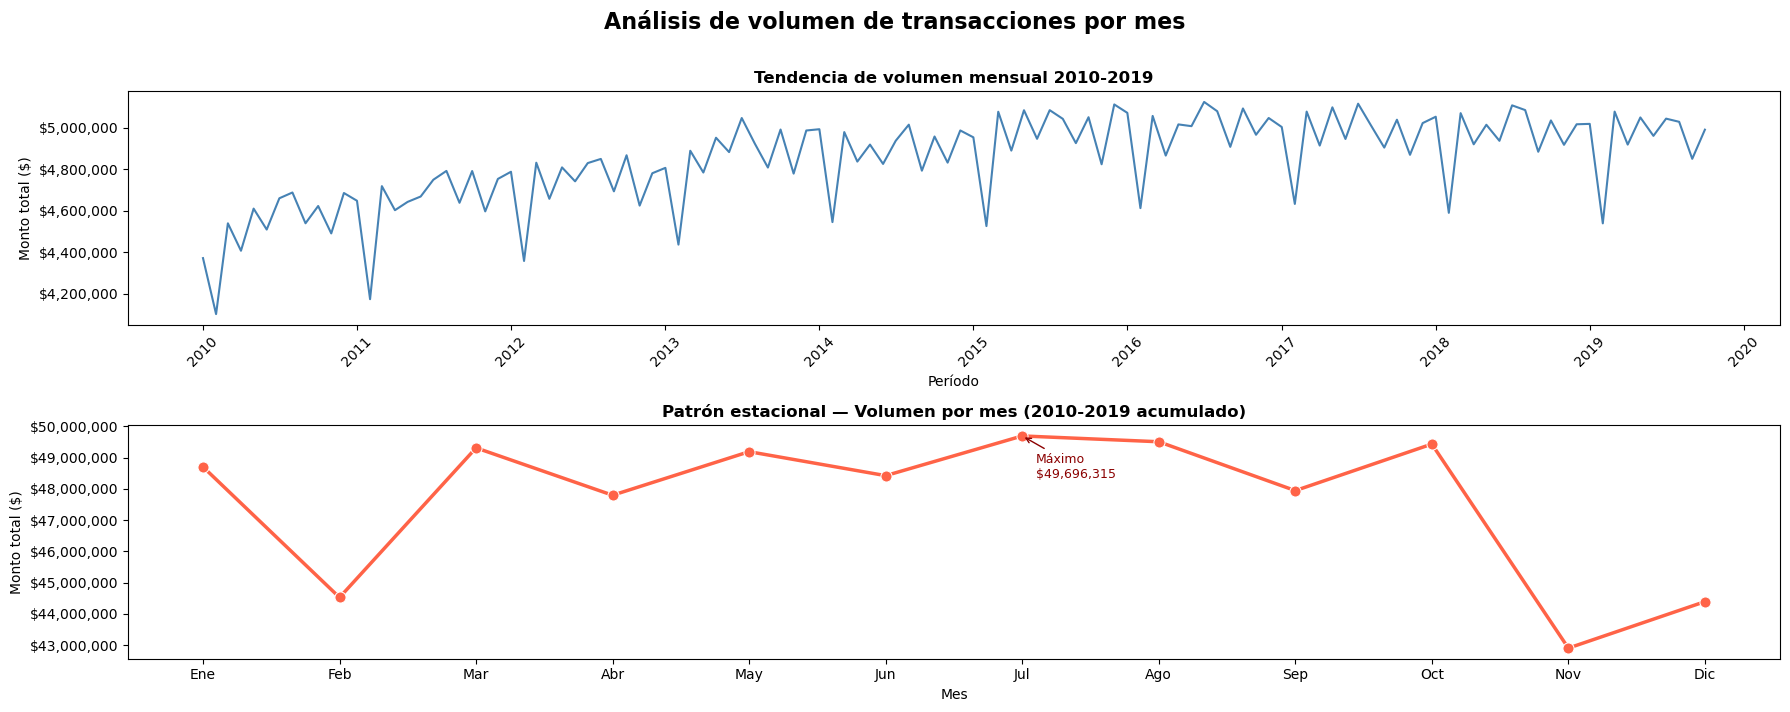

In [36]:
# Graficos
# --- Figura con dos subplots ---
fig, axes = plt.subplots(2, 1, figsize=(18, 7))

# --- Gráfico 1: Tendencia 2010-2019 ---
sns.lineplot( data=tendencia, x='periodo', y='amount', color='steelblue', linewidth=1.5, ax=axes[0])
axes[0].set_title('Tendencia de volumen mensual 2010-2019', fontweight='bold')
axes[0].set_xlabel('Período')
axes[0].set_ylabel('Monto total ($)')
axes[0].tick_params(axis='x', rotation=45)

# --- Gráfico 2: Patrón estacional ---
sns.lineplot( data=estacional,  x='name_month',  y='amount',  color='tomato', linewidth=2.5, marker='o', markersize=8, ax=axes[1])

# Resaltar el mes con mayor volumen
axes[1].annotate(
    f"Máximo\n${mes_max['amount']:,.0f}",
    xy=(mes_max['name_month'], mes_max['amount']),
    xytext=(10, -30),
    textcoords='offset points',
    fontsize=9,
    color='darkred',
    arrowprops=dict(arrowstyle='->', color='darkred')
)
axes[1].set_title('Patrón estacional — Volumen por mes (2010-2019 acumulado)', fontweight='bold')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Monto total ($)')

formatter = FuncFormatter(lambda x, pos: f'${x:,.0f}')

axes[0].yaxis.set_major_formatter(formatter)
axes[1].yaxis.set_major_formatter(formatter)

plt.suptitle('Análisis de volumen de transacciones por mes', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Pregunta 18 - Histograma: distribución de montos de transacciones

In [37]:
# Datos
todos_montos = df['amount']

#IRQ
q1 = todos_montos.quantile(0.25)
q3 = todos_montos.quantile(0.75)
IQR = q3 - q1
limite_inferior = q1 - 1.5 * IQR
limite_superior = q3 + 1.5 * IQR

#Sin outliers
sin_outliers = todos_montos[(todos_montos >= limite_inferior) & (todos_montos <= limite_superior)]

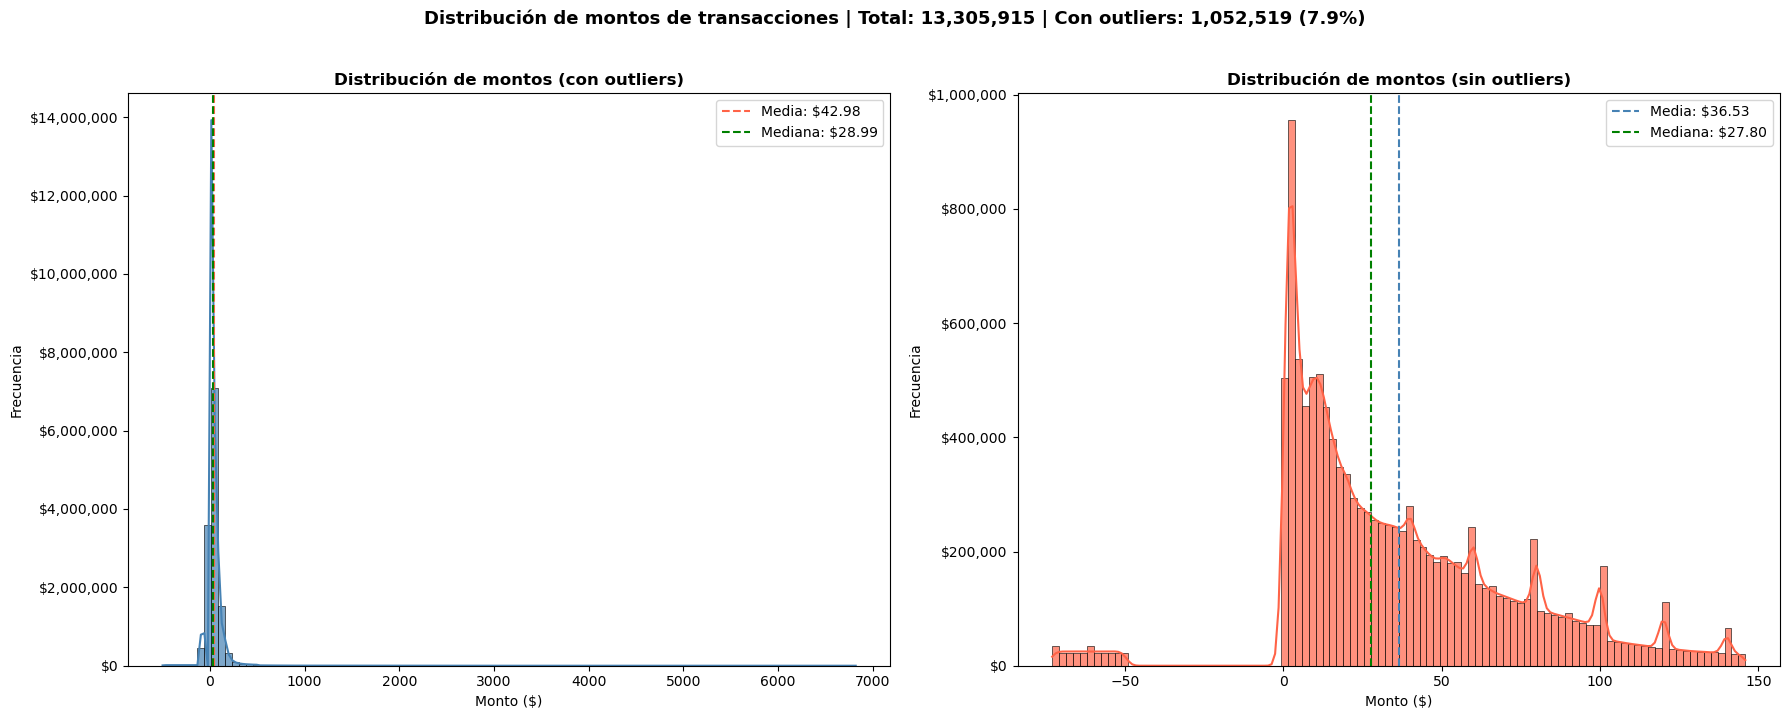

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Gráfico 1: Con outliers ---
sns.histplot(data=todos_montos, bins=100, color='steelblue', alpha=0.7, kde=True, ax=axes[0])
# Limites
axes[0].axvline(todos_montos.mean(), color='tomato', linestyle='--', linewidth=1.5, label=f'Media: ${todos_montos.mean():.2f}')
axes[0].axvline(todos_montos.median(), color='green', linestyle='--', linewidth=1.5, label=f'Mediana: ${todos_montos.median():.2f}')

axes[0].set_title('Distribución de montos (con outliers)', fontweight='bold')
axes[0].set_xlabel('Monto ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# --- Gráfico 2: Sin outliers ---
sns.histplot(data=sin_outliers, bins=100, color='tomato', alpha=0.7, kde=True, ax=axes[1])
# Limites
axes[1].axvline(sin_outliers.mean(), color='steelblue', linestyle='--', linewidth=1.5, label=f'Media: ${sin_outliers.mean():.2f}')
axes[1].axvline(sin_outliers.median(), color='green', linestyle='--', linewidth=1.5, label=f'Mediana: ${sin_outliers.median():.2f}')

axes[1].set_title('Distribución de montos (sin outliers)', fontweight='bold')
axes[1].set_xlabel('Monto ($)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# Eje Y
formatter = FuncFormatter(lambda x, pos: f'${x:,.0f}')

axes[0].yaxis.set_major_formatter(formatter)
axes[1].yaxis.set_major_formatter(formatter)

# Estadísticas en el título
plt.suptitle( 
    f'Distribución de montos de transacciones | '
    f'Total: {len(todos_montos):,} | '
    f'Con outliers: {len(todos_montos) - len(sin_outliers):,} ({(1 - len(sin_outliers)/len(todos_montos))*100:.1f}%)',
                    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

### Pregunta 19 - Pie chart o barras: % de transacciones fraudulentas vs normales

In [39]:
# Datos
df_clasificados = df[df['is_fraud'] != -1]

conteo = df_clasificados['is_fraud'].value_counts()
labels = ['Legítima', 'Fraudulenta']
colores = ['steelblue', 'tomato']
explode = (0, 0.15)  # separa la porción de fraude hacia afuera

In [44]:
cat_fraude = df_clasificados[df_clasificados["is_fraud"] != -1]

top_cat_fraude = (cat_fraude
    .groupby("categoria")
    .agg(
        total_transaction=('is_fraud', 'count'),
        total_fraud=('is_fraud', 'sum')
    )
    .reset_index()
)
top_cat_fraude['porcentaje'] = (top_cat_fraude['total_fraud']/top_cat_fraude['total_transaction']*100).round(2)

top_cat_fraude = top_cat_fraude.sort_values(by="porcentaje", ascending=False)
top_cat_fraude.head()

,categoria,total_transaction,total_fraud,porcentaje
24,Cruise Lines,276,165,59.78
73,Music Stores - Musical Instruments,204,76,37.25
63,Miscellaneous Fabricated Metal Products,245,29,11.84
22,"Computers, Computer Peripheral Equipment",1883,204,10.83
40,Floor Covering Stores,222,23,10.36


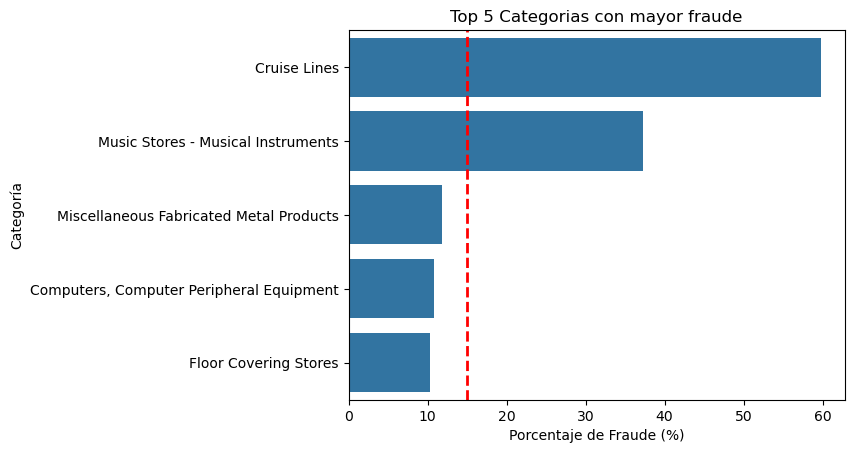

In [50]:
top_5_cat_fraude = top_cat_fraude.head()

sns.barplot(data=top_5_cat_fraude, x="porcentaje", y="categoria")
plt.title("Top 5 Categorias con mayor fraude")
plt.xlabel("Porcentaje de Fraude (%)")
plt.ylabel("Categoría")
# Promedio general de fraude
plt.axvline(x=15, color='red', linestyle='--', linewidth=2)

plt.show()

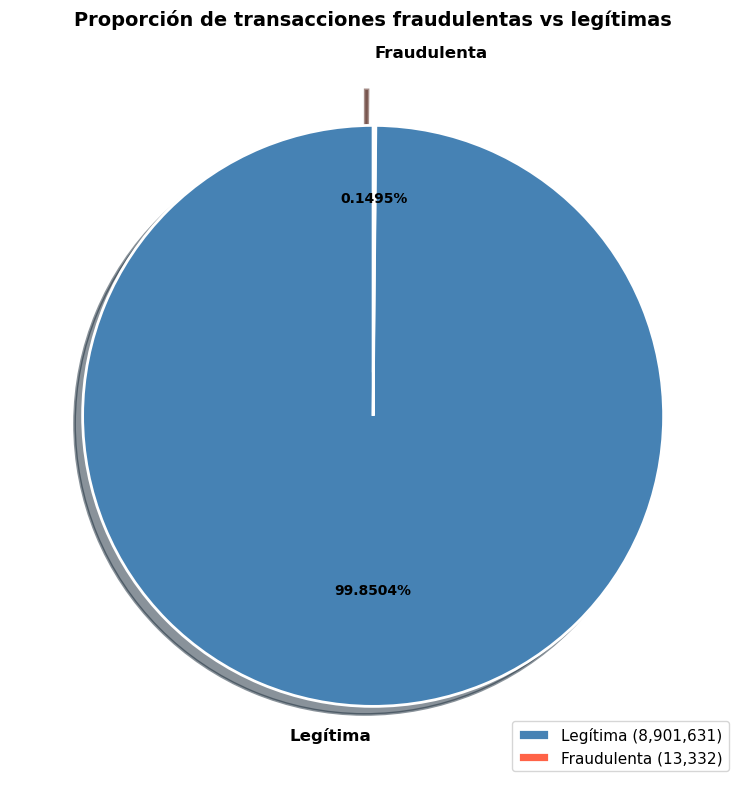

In [41]:
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    conteo,
    labels=labels,
    colors=colores,
    explode=explode,
    autopct='%1.4f%%',     # 4 decimales para ver el 0.15%
    startangle=90,          
    shadow=True,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

# Hacer las etiquetas más legibles
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('black')
    autotext.set_fontweight('bold')

ax.set_title(
    'Proporción de transacciones fraudulentas vs legítimas',
    fontweight='bold', fontsize=14, pad=20
)

# Agregar conteos absolutos en la leyenda
legitimas = conteo.iloc[0]
fraudulentas = conteo.iloc[1]
ax.legend(
    [f'Legítima ({legitimas:,})', f'Fraudulenta ({fraudulentas:,})'],
    loc='lower right',
    fontsize=11
)

plt.tight_layout()
plt.show()

### Pregunta 20 - Boxplot: comparación de montos entre transacciones normales y fraudulentas

In [42]:
# Datos
# Usar solo transacciones clasificadas y sin outliers extremos
df_normales_fraudulentas = df[
    (df['is_fraud'] != -1) &
    (df['amount'] >= limite_inferior) &
    (df['amount'] <= limite_superior)
].copy()

df_normales_fraudulentas['tipo'] = df_normales_fraudulentas['is_fraud'].map({0: 'Legítima', 1: 'Fraudulenta'})

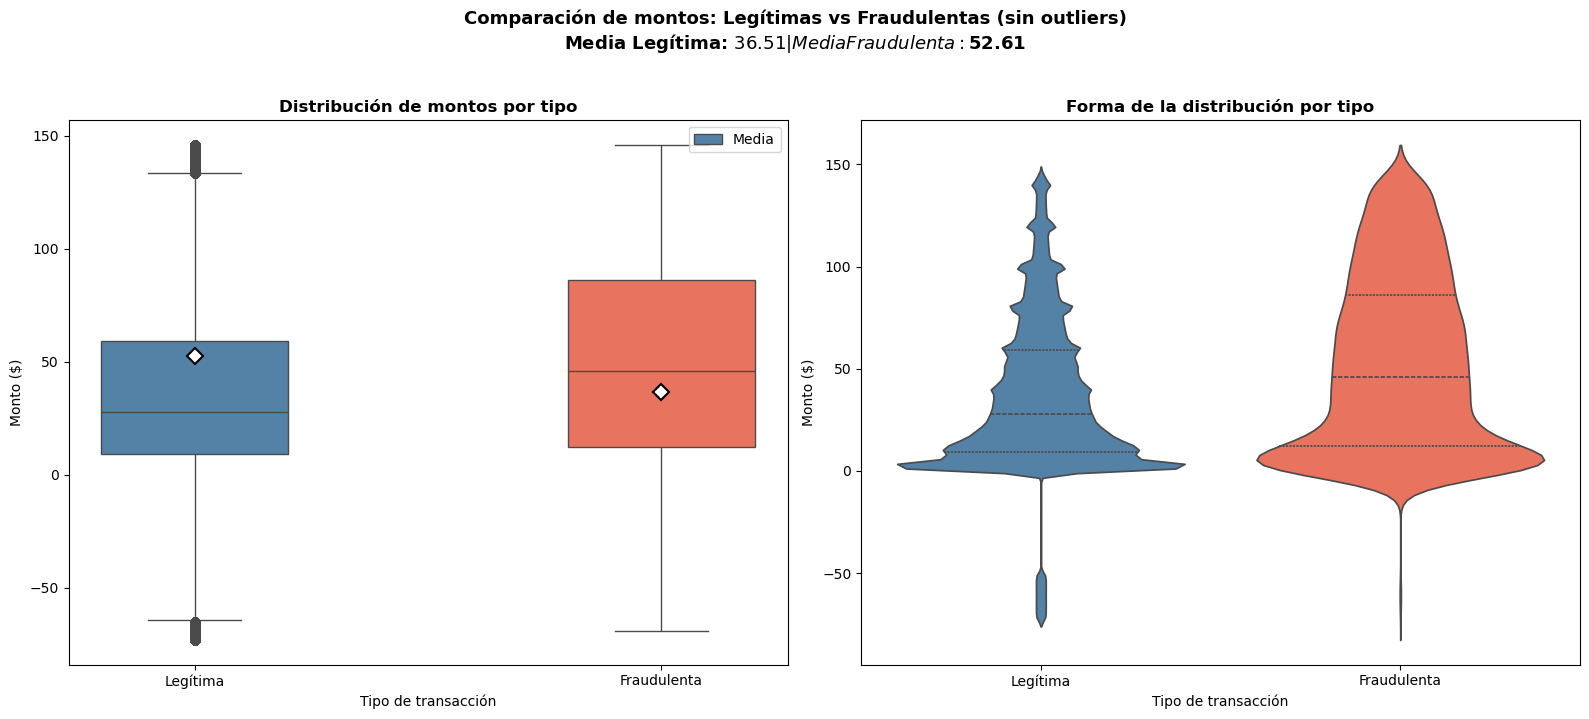

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Gráfico 1: Boxplot ---
sns.boxplot(data=df_normales_fraudulentas, x='tipo', y='amount', hue='tipo', 
            palette={'Legítima': 'steelblue', 'Fraudulenta': 'tomato'}, width=0.4, legend=False, ax=axes[0])

# Agregar el promedio como punto
medias = df_normales_fraudulentas.groupby('tipo')['amount'].mean()
for i, (tipo, media) in enumerate(medias.items()):
    axes[0].plot(i, media, 'D',          # D = diamante
                color='white',
                markersize=8,
                markeredgecolor='black',
                markeredgewidth=1.5,
                zorder=5,
                label='Media' if i == 0 else '')

axes[0].set_title('Distribución de montos por tipo', fontweight='bold')
axes[0].set_xlabel('Tipo de transacción')
axes[0].set_ylabel('Monto ($)')
axes[0].legend(['Media'], loc='upper right')

# --- Gráfico 2: Violin plot (complemento al boxplot) ---
sns.violinplot(data=df_normales_fraudulentas, x='tipo', y='amount', hue='tipo', palette={'Legítima': 'steelblue', 'Fraudulenta': 'tomato'},
    inner='quartile',    # muestra Q1, mediana y Q3 dentro del violín
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Forma de la distribución por tipo', fontweight='bold')
axes[1].set_xlabel('Tipo de transacción')
axes[1].set_ylabel('Monto ($)')

# --- Estadísticas en el título ---
media_leg = medias.get('Legítima', 0)
media_fra = medias.get('Fraudulenta', 0)

plt.suptitle(
    f'Comparación de montos: Legítimas vs Fraudulentas (sin outliers)\n'
    f'Media Legítima: ${media_leg:.2f} | Media Fraudulenta: ${media_fra:.2f}',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()